# Stellar Luminosity — Part I  
## Linear Regression (One Feature) 

---

### Objective
Model stellar luminosity **L** as a function of stellar mass **M** using a linear regression model with an explicit bias term:

$$
\hat{L} = w\,M + b
$$




### Required Tasks
1. **Dataset visualization:** plot $M$ vs $L$ and comment on linearity/plausibility.  
2. **Model & loss:** implement prediction and mean squared error (MSE).  
3. **Cost surface (mandatory):** evaluate $J(w,b)$ on a grid and plot a 3D surface or contour; explain the minimum.  
4. **Gradients:** derive and implement $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$.  
5. **Gradient descent (non-vectorized):** compute gradients using an explicit loop over samples.  
6. **Gradient descent (vectorized):** compute gradients using NumPy vectorization (no loop over samples).  
7. **Convergence (mandatory):** plot loss vs iterations and comment on speed/stability.  
8. **Experiments (mandatory):** run at least three learning rates; report final $w$, $b$, and loss.  
9. **Final fit plot:** plot the regression line over the data and discuss systematic errors.  
10. **Conceptual questions:** astrophysical meaning of $w$; why linear is limited here.


### Allowed Libraries
- Python
- NumPy
- Matplotlib (inline plots only)

### Not Allowed
- scikit-learn
- statsmodels
- TensorFlow / PyTorch
- Any high-level regression / optimization library

---

### Notation
- **M**: stellar mass (in units of solar mass, $M_\odot$)
- **L**: stellar luminosity (in units of solar luminosity, $L_\odot$)


In [2]:
%pip install numpy pandas matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:

import numpy as np
import matplotlib.pyplot as plt

---


## 0. Dataset Definition

- **M** = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]  
- **L** = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]


In [4]:

M = np.array([0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4])
L = np.array([0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0])

---


## 1. Dataset Visualization


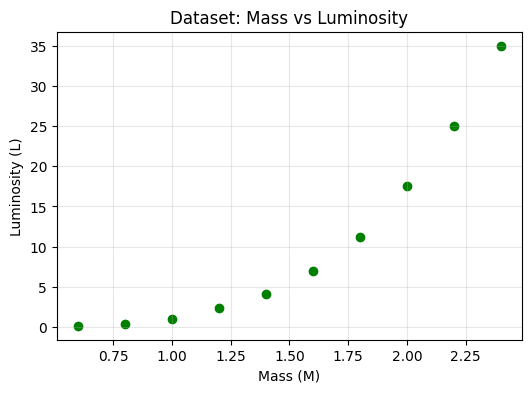

In [5]:

plt.figure(figsize=(6,4))
plt.scatter(M, L, color='Green')
plt.xlabel("Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Dataset: Mass vs Luminosity")
plt.grid(True, alpha=0.3)
plt.show()


#### *Linealidad*
En la gráfica se observa el conjunto de puntos tiene una tendencia mas creciente que lineal, observo que la grafica tiene una tendencia mas a lo exponencial debido a que para valores pequeños de la masa la luminosidad no aumenta tan rapido sino mas gradual, en cambio a medida que M aumenta L toma valores mucho mas grandes y crece muy rapido asi que se convierte en una relacion mas exponencial que lineal.

#### *Plausibilidad*
Para una primera aproximación usar un modelo lineal es correcto al tener valores pequeños de masas y donde el crecimiento de los valores de L no es tan rapido, sin embargo cuando la masa aumenta el modelo lineal ya no seria un buena representación ya que no se tendria una aproximación tan cercana y con un error no tan grande.

---

## 2. Model and Loss Function

### 2.1 Hypothesis (Prediction)


$$
\hat{L}^{(i)} = w\,M^{(i)} + b
$$

### 2.2 Loss (Mean Squared Error)


$$
J(w,b) = \frac{1}{2n}\sum_{i=1}^{n} \left(\hat{L}^{(i)} - L^{(i)}\right)^2
$$



In [6]:

def predict(M, w, b):
    """Compute the predicted L values for given M, using f_{w,b}(M) = w * M + b."""
    return w * M + b

def error_mse(M, L, w, b):
    """Compute the Mean Squared Error loss between predicted and actual L values."""
    n = M.shape[0]
    L_hat = predict(M, w, b)
    error = L_hat - L
    mse = (1/2*n) * np.sum(error ** 2)

    return mse

---

## 3. Cost Surface $J(w,b)$ (Mandatory)


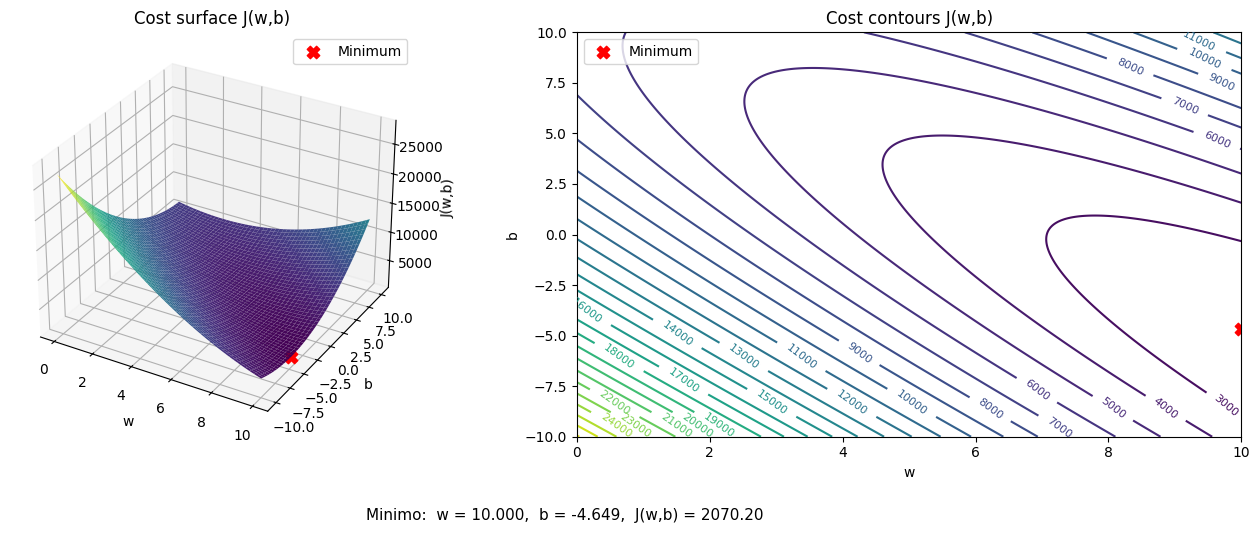

In [7]:
from matplotlib import cm

w_values = np.linspace(0, 10, 300)
b_values = np.linspace(-10, 10, 300)

W, B = np.meshgrid(w_values, b_values)
J_vals = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = error_mse(M, L, W[i, j], B[i, j])


min_idx = np.unravel_index(np.argmin(J_vals), J_vals.shape)
w_min = W[min_idx]
b_min = B[min_idx]
J_min = J_vals[min_idx]


fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax2 = fig.add_subplot(1, 2, 2)


ax1.plot_surface(W, B, J_vals, cmap=cm.viridis, linewidth=0, antialiased=True)
ax1.scatter(w_min, b_min, J_min, color='red', marker='X', s=80, label="Minimum")
ax1.set_xlabel("w")
ax1.set_ylabel("b")
ax1.set_zlabel("J(w,b)")
ax1.set_title("Cost surface J(w,b)")
ax1.legend()


contours = ax2.contour(W, B, J_vals, levels=30)
ax2.clabel(contours, inline=True, fontsize=8)
ax2.scatter(w_min, b_min, color='red', marker='X', s=80, label="Minimum")
ax2.set_xlabel("w")
ax2.set_ylabel("b")
ax2.set_title("Cost contours J(w,b)")
ax2.legend()


fig.text(
    0.5, -0.05,
    f"Minimo:  w = {w_min:.3f},  b = {b_min:.3f},  J(w,b) = {J_min:.2f}",
    ha="center",
    fontsize=11
)

plt.tight_layout()
plt.show()




#### *¿Que representa el mínimo?*
El mínimo de la superficie representa la combinación de los valores que pueden tomar w y b para la cual el error MSE es el más pequeño posible. En ese punto, el modelo lineal logra la aproximación más cercana a los datos observados dentro de las limitaciones del propio modelo. A medida que aumenta el número de iteraciones, el algoritmo de gradient descent ajusta los valores de wy bde manera progresiva, buscando acercarse cada vez más a ese mínimo de la superficie de costo.

Además, este mínimo corresponde al mejor ajuste global del modelo, ya que para cualquier otra combinación de w y b el error sería mayor. La forma convexa de la superficie indica que existe un único mínimo, lo que garantiza que el algoritmo puede converger de manera estable si se elige una tasa de aprendizaje adecuada.


---

## 4. Gradients (Derive + Implement)


$$
\hat{L}^{(i)} = wM^{(i)} + b, \quad
J(w,b) = \frac{1}{2n}\sum_{i=1}^{n} \left(\hat{L}^{(i)} - L^{(i)}\right)^2
$$

**Gradients**
$$
\frac{\partial J}{\partial w} = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{L}^{(i)} - L^{(i)}\right)M^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{n}\sum_{i=1}^{n}\left(\hat{L}^{(i)} - L^{(i)}\right)
$$


In [8]:

def calcularGradientes(M, L, w, b):
    n = M.shape[0]
    L_hat = predict(M, w, b)
    errors = L_hat - L

    dj_dw = (1/n) * np.sum(errors * M)
    dj_db = (1/n) * np.sum(errors)

    return dj_dw, dj_db

---

## 5. Gradient Descent (Non-Vectorized Gradients)



$$
w := w - \alpha\,\frac{\partial J}{\partial w}, \quad
b := b - \alpha\,\frac{\partial J}{\partial b}
$$




In [9]:
M_noVec = [0.6, 0.8, 1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4]
L_noVec = [0.15, 0.35, 1.00, 2.30, 4.10, 7.00, 11.2, 17.5, 25.0, 35.0]

def predict_noVec(M_List, w, b):
    L_hat_list = []
    for i in range(len(M_list)):
        L_hat_list.append(w * M_list[i] + b)
    return L_hat_list

def error_mse_noVec(M_List, L_List, w, b):
    n_local = len(M_List)
    total = 0.0
    for i in range(n_local):
        f_wb = w * M_List[i] + b
        error = f_wb - L_List[i]
        total += error ** 2

    costo = total / (2 * n_local)
    return costo

def calcularGradientes_noVec(M_List, L_List, w, b):
    n_local = len(M_List)
    sum_dw = 0.0
    sum_db = 0.0

    for i in range(n_local):
        f_wb = w * M_List[i] + b
        error = f_wb - L_List[i]
        sum_dw += error * M_List[i]
        sum_db += error

    dj_dw = sum_dw / n_local
    dj_db = sum_db / n_local
    return dj_dw, dj_db

def gradient_descent_noVec(M_List, L_List, w_init, b_init, alpha, num_iterations):

    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = calcularGradientes_noVec(M_List, L_List, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        
        cost = error_mse_noVec(M_List, L_List, w, b)
        history.append((i, cost))
        
        
        if i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")


    return w, b, history


alpha = 0.1
num_iterations = 1000  
w_init = 0.0  
b_init = 0.0  

w_final, b_final, history = gradient_descent_noVec(M, L, w_init, b_init, alpha, num_iterations)
print("\nParametros aprendidos:")
print("w =", w_final)
print("b =", b_final)

Iteration    0: w= 2.1523, b= 1.0360, cost= 70.4969
Iteration  100: w=13.4290, b=-9.0460, cost= 13.7140
Iteration  200: w=16.3146, b=-13.8270, cost= 10.3797
Iteration  300: w=17.4290, b=-15.6735, cost=  9.8823
Iteration  400: w=17.8595, b=-16.3867, cost=  9.8082
Iteration  500: w=18.0257, b=-16.6621, cost=  9.7971
Iteration  600: w=18.0899, b=-16.7685, cost=  9.7954
Iteration  700: w=18.1147, b=-16.8096, cost=  9.7952
Iteration  800: w=18.1243, b=-16.8255, cost=  9.7952
Iteration  900: w=18.1280, b=-16.8316, cost=  9.7951

Parametros aprendidos:
w = 18.129395435290267
b = -16.83395077119689


---

## 6. Gradient Descent (Vectorized Gradients)

$$
w := w - \alpha\,\frac{\partial J}{\partial w}, \quad
b := b - \alpha\,\frac{\partial J}{\partial b}
$$



In [10]:

def gradient_descent(M_List, L_List, w_init, b_init, alpha, num_iterations, show=True):

    w = w_init
    b = b_init
    history = []

    for i in range(num_iterations):
        dj_dw, dj_db = calcularGradientes(M_List, L_List, w, b)

        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        
        cost = error_mse(M_List, L_List, w, b)
        history.append((i, cost))
        
        
        if show and i % max(1, (num_iterations // 10)) == 0:
            print(f"Iteration {i:4d}: w={w:7.4f}, b={b:7.4f}, cost={cost:8.4f}")


    return w, b, history


alpha = 0.1  
num_iterations = 1000  
w_init = 0.0  
b_init = 0.0  

w_learned, b_learned, history = gradient_descent(M, L, w_init, b_init, alpha, num_iterations, show=True)
print("\nParametros aprendidos:")
print("w =", w_learned)
print("b =", b_learned)

Iteration    0: w= 2.1523, b= 1.0360, cost=7049.6949
Iteration  100: w=13.4290, b=-9.0460, cost=1371.3963
Iteration  200: w=16.3146, b=-13.8270, cost=1037.9711
Iteration  300: w=17.4290, b=-15.6735, cost=988.2347
Iteration  400: w=17.8595, b=-16.3867, cost=980.8156
Iteration  500: w=18.0257, b=-16.6621, cost=979.7089
Iteration  600: w=18.0899, b=-16.7685, cost=979.5438
Iteration  700: w=18.1147, b=-16.8096, cost=979.5192
Iteration  800: w=18.1243, b=-16.8255, cost=979.5155
Iteration  900: w=18.1280, b=-16.8316, cost=979.5149

Parametros aprendidos:
w = 18.129395435290267
b = -16.833950771196893


## 7. Convergence Plot (Mandatory)


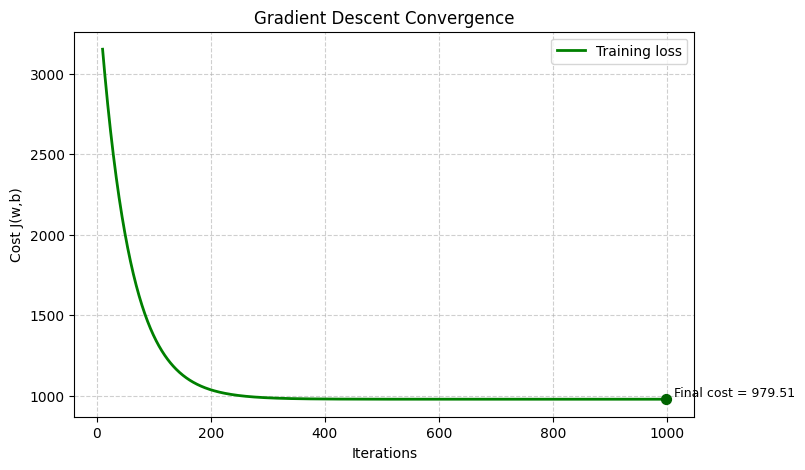

In [11]:

plt.figure(figsize=(8, 5))

plt.plot(
    [h[0] for h in history][10:],
    [h[1] for h in history][10:],
    color="green",
    linewidth=2,
    label="Training loss"
)

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Gradient Descent Convergence")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()


final_iter = history[-1][0]
final_cost = history[-1][1]
plt.scatter(final_iter, final_cost, color="darkgreen", s=50, zorder=5)
plt.text(
    final_iter, final_cost,
    f"  Final cost = {final_cost:.2f}",
    fontsize=9,
    verticalalignment="bottom"
)

plt.show()



#### *Convergencia y Estabilidad*
En esta gráfica se observa que, durante las primeras iteraciones, el costo disminuye a una velocidad muy alta. Esto indica que el algoritmo de gradient descent realiza ajustes grandes en los valores de w y b, acercándose rápidamente al mínimo de la función de costo.

También la gráfica muestra que a medida que aumenta el número de iteraciones, la velocidad con la que disminuye el costo es más lenta y el descenso se vuelve más suave. Esto ocurre porque, cerca del mínimo, los gradientes son cada vez más pequeños, lo que produce actualizaciones menores en los parámetros. Este comportamiento muestra que el algoritmo presenta una convergencia estable, ya que no se observan oscilaciones ni divergencia, sino que el modelo se aproxima de forma gradual al mínimo.


---

## 8. Learning Rate Experiments (Mandatory)


Alpha: 0.001, w: 6.7737785583999575, b: 1.5787460037920253, Cost: 3202.6696691114353
Alpha: 0.01, w: 13.364761102627167, b: -8.939532714878704, Cost: 1382.1822375363263
Alpha: 0.5, w: 18.13030303030302, b: -16.835454545454525, Cost: 979.5148484848488


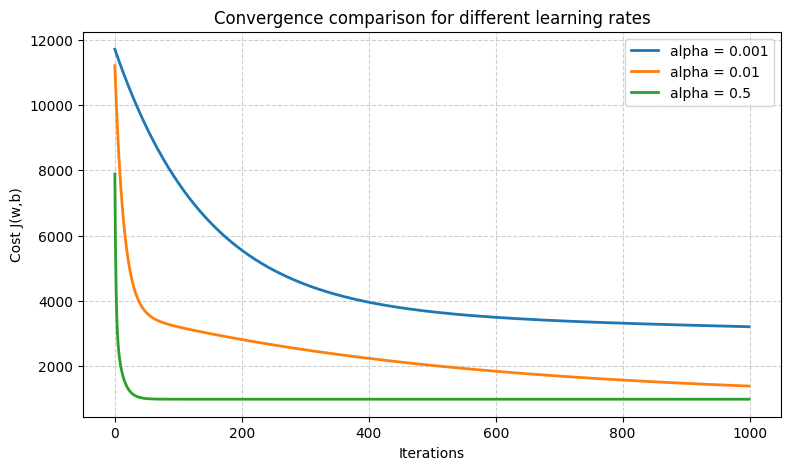

In [12]:
learning_rates = [0.001, 0.01, 0.5]
num_iterations = 1000
w_init = 0.0
b_init = 0.0

results = []
histories = {}  

for alpha in learning_rates:
    w_final, b_final, history = gradient_descent(
        M, L, w_init, b_init, alpha, num_iterations, show=False
    )
    
    cost = history[-1][1]
    
    results.append({
        "alpha": alpha,
        "w": w_final,
        "b": b_final,
        "cost": cost
    })
    
    histories[alpha] = history  


for j in results:
    print(f"Alpha: {j['alpha']}, w: {j['w']}, b: {j['b']}, Cost: {j['cost']}")


plt.figure(figsize=(9, 5))

for alpha in learning_rates:
    iters = [h[0] for h in histories[alpha]]
    costs = [h[1] for h in histories[alpha]]
    plt.plot(iters, costs, linewidth=2, label=f"alpha = {alpha}")

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")

plt.title("Convergence comparison for different learning rates")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


#### *Resultados Observados*
Se utilizaron tres tasas de aprendizaje diferentes. Para el primer caso, con un learning rate pequeño (0.001), se observa que el algoritmo converge de manera estable; sin embargo, el costo final sigue siendo relativamente alto, esto muestta que la convergencia es lenta para el número de iteraciones utilizado.

En la segunda tasa de aprendizaje (0.01), se puede ver que el costo disminuye de forma significativa, logrando un mejor ajuste del modelo con las mismas iteraciones. Este valor representa un buen equilibrio entre velocidad de convergencia y estabilidad.

Por último, con una tasa de aprendizaje más grande (0.5), se obtiene el costo más pequeño; pero los valores de w y bcambian de manera mucho más drástica en comparación con los casos anteriores. Esto muestra que aunque el error se reduce rápidamente, el algoritmo puede volverse inestable y existe el riesgo de oscilaciones o divergencia si se incrementa aún más la tasa de aprendizaje.


---

## 9. Final Fit Visualization


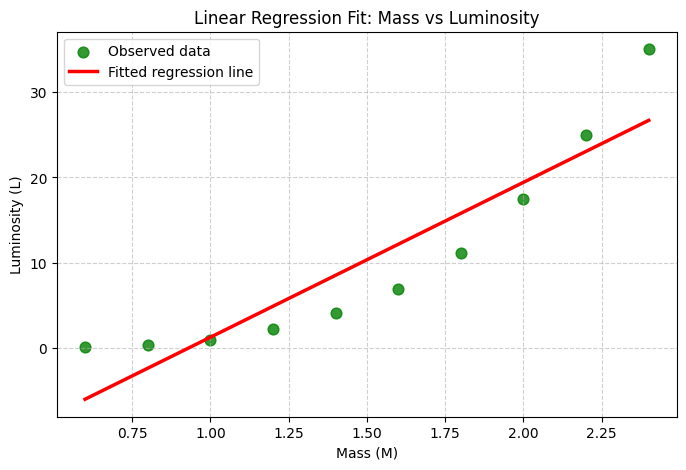

In [13]:

plt.figure(figsize=(8, 5))

plt.scatter(
    M, L,
    color="green",
    s=60,
    alpha=0.8,
    label="Observed data"
)

L_pred = predict(M, w_learned, b_learned)
plt.plot(
    M, L_pred,
    color="red",
    linewidth=2.5,
    label="Fitted regression line"
)

plt.xlabel("Mass (M)")
plt.ylabel("Luminosity (L)")
plt.title("Linear Regression Fit: Mass vs Luminosity")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


#### *Conclusiones*
En esta gráfica se identifican errores sistemáticos en el ajuste del modelo, para valores pequeños de la masa estelar, la recta se aproxima a los datos, aunque en algunos puntos la recta se ajusta un poco por encima de los valores reales. Sin embargo, cuando la masa es mayor, la recta ya no logra alcanzar los valores reales de la luminosidad, ya que los puntos observados se encuentran cada vez más por encima de la recta ajustada.

Este patrón de error muestra que el modelo no es el más adecuado para representar la relación real entre la masa y la luminosidad. En este conjunto de datos, la luminosidad aumenta cada vez más rápido a medida que la masa crece, lo que indica que la relación no es lineal. Por esta razón, el modelo lineal tiene limitaciones, ya que no logra ajustarse bien a los valores de luminosidad para masas grandes, lo que hace necesario usar modelos no lineales o polinomiales para obtener una mejor aproximación 

---


## 10. Conceptual Questions 

### *10.1 Astrophysical meaning of $w$*

En este modelo lineal, el parámetro w representa la tasa a la cual cambia la luminosidad de una estrella cuando aumenta su masa. Desde un punto de vista astrofísico,  w puede interpretarse como una medida de qué tan sensible es la luminosidad ante cambios en la masa estelar dentro del rango de datos analizado. Es decir, indica cuánto aumenta la luminosidad, en promedio, por cada unidad adicional de masa.

### *10.2 Why is a linear model limited here?*

Un modelo lineal es limitado en este caso porque asume que la luminosidad aumenta de manera constante con la masa, y esto no refleja el comportamiento real de las estrellas. En el conjunto de datos se observa que a medida que la masa aumenta, la luminosidad crece cada vez más rápido, esto muestra que no es una relación no lineal. Debido a esta aceleración en el crecimiento, una recta no puede ajustarse correctamente a todos los puntos, especialmente para masas grandes, generando errores sistemáticos, por esto  se requieren modelos no lineales o polinomiales que puedan representar mejor esta relación.

---